# Cosmology with GWs/FRBs Associations MCMC version

In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

### MCMCM packages
path='../FRB_cosmo/interpolation/095_C0mean.npz' # './interpolation/StandardD_C0mean.npz' 

import mcmc_support_GW_FRB
mcmc_support_GW_FRB.DATA_PATH = path
mcmc_support_GW_FRB.reload_with_path(path)
from mcmc_support_GW_FRB import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


-------------------------------------------------------------

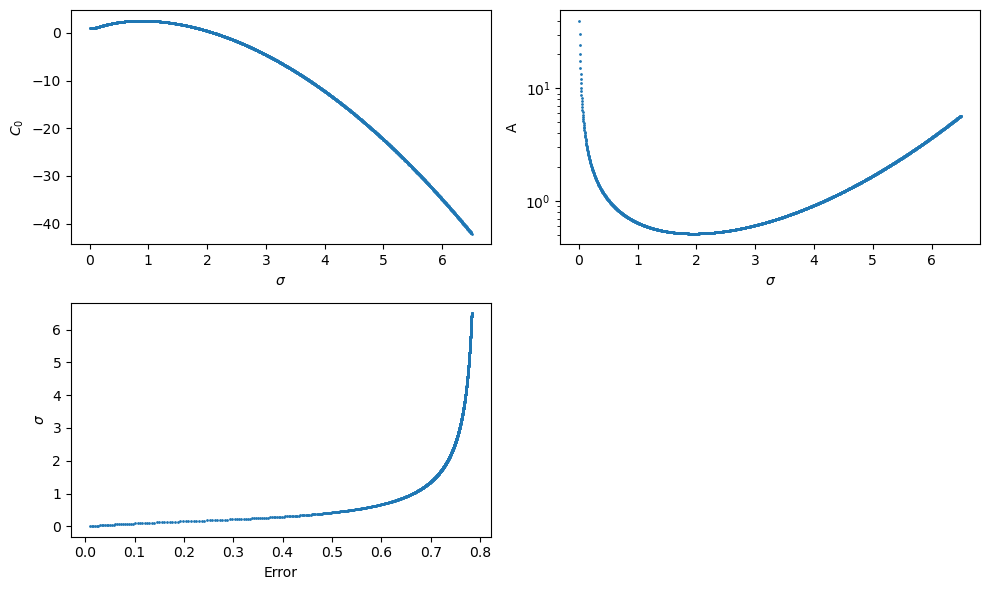

In [2]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.scatter(Sigmas, C0s,  s=1)
ax1.set_ylabel(r'$C_0$')
ax1.set_xlabel(r'$\sigma$')

ax2.scatter(Sigmas, As,  s=1)
ax2.set_ylabel('A')
ax2.set_xlabel(r'$\sigma$')
ax2.set_yscale('log')

ax3.scatter(Errors, Sigmas,s=1)
ax3.set_ylabel(r'$\sigma$')
ax3.set_xlabel(r'Error')

plt.tight_layout()
plt.show()

# Table of Contents <a name="toc"></a>

1. [Basic definitions](#Definitions)
2. [Checking with Wei et al.](#Reproduction_Results_Wei_et_al)
3. [Cosmo inference without redshift - precise distance info](#Precise_distance_info)
4. [Cosmo inference without redshift - uncertain distance info](#Uncertain_distance_info)
5. [Finding the missing baryons with Macquart et al.](#Macquart_paper)

----------------------------------------------

## Basic definitions <a name="Definitions"></a>

We are defining the **luminosity distance**, observed through GWs:

$$
d_L = \frac{(1+z) c}{H_0} \int_0^z \frac{dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}}.
$$

For a cosmological constant, we have $w=-1$.

We are defining the IGM **dispersion measure (DM)**, based on [[Deng & Zhang, 2014](https://iopscience.iop.org/article/10.1088/2041-8205/783/2/L35/pdf)], eq. (13) and eq. (12) of [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)]:

$$
{\rm DM}_{\rm IGM} = \frac{3 c H_0 \Omega_b f_{\rm IGM}}{8 \pi G m_p} \int_0^z \frac{\chi(z) (1+z) dz}{\sqrt{\Omega_m(1+z)^3+(1-\Omega_m)(1+z)^{3(1+w)}}} 
$$


Assuming redshifts $z<2$, we use $\chi(z) \simeq 7/8$ - this assumes that the Universe is fully ionised at that time. For higher redshifts, the ionisation history of H and He needs to be modelled.

-----------------------------------------

## 1. $D_L$ & $DM_{diff}$ constraints <a name="D_L DM_diff"></a>

**Creation of mock events** (simplified)

We draw some random redshifts from $[z_{\min}, z_{\max}]$. For these, and the fiducial cosmology, we calculate luminosity distances and DMs, and their respective errors. The mock obsersations are based on these but with scatter that follows a guassian distribution, e.g. ${\rm DM}^{\rm obs} = \mathcal{N}({\rm DM}(z, H^f_0, \Omega_m^f, w^f), \sigma_{\rm DM})$.

We then use the redshifts and the $\chi^2$ statistic to put constraints on $\Omega_m$ and $w$.

Return to TOC [here](#toc).

In [3]:
# Find use quadratic function may get negative error in some large redshift

def GW_error_LVK(z, H0, Om, w=-1, order=1):
    if (order==1):
        a0=19.202
        a1=86.773
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=17.015
        a1=131.750
        a2=-174.911
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')
    
def GW_error_CE(z, H0, Om, w=-1, order=2):
    if (order==1):
        a0=9.792
        a1=9.704
        dL=luminosity_distance(z, H0, Om, w)
        return (a1*z+a0)*dL
    elif (order==2):
        a0=7.649
        a1=18.581
        a2=-4.559
        dL=luminosity_distance(z, H0, Om, w)
        return (a2*z*z+a1*z+a0)*dL
    else:
        print('Choose order from 1 or 2. Use default instead')
        return sigma_dL(z_val, H0, Om, w=w, method='Wei')

## Generate events

**For FRB DM, try to use Macquart pdf**

$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$

$$ <DM_{diff}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

$ p_{diff}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{diff}^2}\right) $

$ \sigma_{diff} $ dominated by physical variance in $DM_{diff}$

$\Delta=DM_{diff}/<DM_{diff}>$

$ \sigma_{diff}(\sigma_{\Delta}(S,z)) $

Which 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$ in Macquart paper.

### Load interpolation

In [4]:
""" S=0.133
EXP_MU=182.937
SIGMA_HOST=0.605
DM_MWHALO=30
HOF=2.813

load_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')
# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )    
    
## Interpolation of C0 terms (see Macquart+ paper)
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    fill_value='extrapolate'
    )

## Interpolation of normalisation factor (so that pdf is normalised to 1)
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    fill_value='extrapolate'
) """

" S=0.133\nEXP_MU=182.937\nSIGMA_HOST=0.605\nDM_MWHALO=30\nHOF=2.813\n\nload_arrays=np.load('../FRB_cosmo/interpolation/095_C0mean.npz')\n# load_arrays=np.load('./interpolation/StandardD_C0mean.npz')\nSigmas=load_arrays['a']\nErrors=load_arrays['d']\nC0s=load_arrays['c']\nAs=load_arrays['b']\n\nsigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )    \n    \n## Interpolation of C0 terms (see Macquart+ paper)\nC0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n    )\n\n## Interpolation of normalisation factor (so that pdf is normalised to 1)\nA_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, \n    fill_value='extrapolate'\n) "

### Cosmological constraints

Generate events from $p_\Delta(\Delta)$. Note that $p_{DM_{diff}}(DM_{diff})d DM_{diff}=p_\Delta(\Delta) d\Delta$, so we have $p_{DM_{diff}}(DM_{diff})=p_\Delta(\Delta) /<DM>$

Now take into account that distances & $DM_{diff}$. To calculate the cosmological parameters, we'll follow a Bayesian approach:

$$
P(\mathbf{H_0}|d_L^{\rm obs}, {\rm DM}^{\rm obs}) \sim \pi(\mathbf{H_0}) \cdot P(d_L^{\rm obs}, {\rm DM}^{\rm obs}|\mathbf{H_0}) = \\
\pi(\mathbf{H_0}) \int dz \ P\left(d_L^{\rm obs}|d_L(z,\mathbf{H_0})\right) \cdot P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) \cdot \pi(z)
$$
where with $\mathbf{H_0}$ we denote the _vector_ of cosmological parameters ($H_0, \Omega_m, w$) and $\pi(z)$ is the prior on the redshift distribution of sources and $\pi(\mathbf{H_0})$ the priors on the cosmological parameters. 

For the ${\rm DM}$ part, we can introduce the contributions of different sources as systematic errors and marginalise over them. In reality, we can estimate ${\rm DM}_{\rm diff}$ as:

$$
{\rm DM}_{\rm diff} = {\rm DM}_{\rm obs} - {\rm DM}_{\rm MW} - {\rm DM}_{\rm host}/(1+z), 
$$

where ${\rm DM}_{\rm MW} = {\rm DM}_{\rm MW, halo} + {\rm DM}_{\rm MW, ISM}$. So we can write $P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right)$ as:

$$
P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}) \right) = \int d{\rm DM}^{\rm MW} d{\rm DM}^{\rm HG} \pi({\rm DM}^{\rm MW}) \pi({\rm DM}^{\rm HG}) P\left({\rm DM}^{\rm obs}|{\rm DM}(z, \mathbf{H_0}), {\rm DM}^{\rm MW}, {\rm DM}^{\rm HG} \right).
$$

We infer:

- $H_0$ with $\Omega_m, w$ fixed to their fiducial values
- $H_0, \Omega_m$ with $w$ fixed to its fiducial value
- $H_0, \Omega_m, w$

#### Simplified version: **$p(z)\sim 1$**

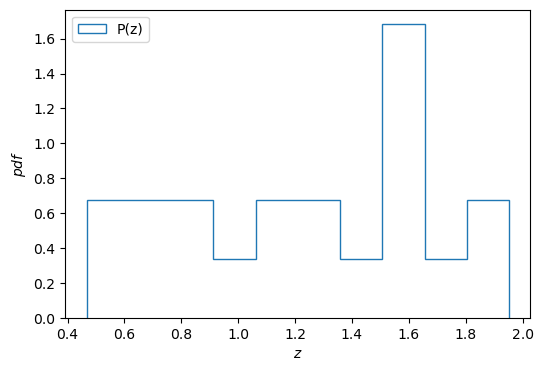

In [5]:
""" ## Random choice of redshift
z_range = np.linspace(0.05, 2, 500)
z_centre = draw_redshift_distribution(z_range, H0=HUBBLE, Omega_m=OMEGA_MATTER, N_draws=20, method='rates') """

fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(z_centre, density=True, histtype='step', label='P(z)')
# ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

In [6]:
print(f"z={z_centre}")

z=[1.18476954 1.898998   1.52024048 1.5490982  0.46693387 1.07655311
 0.82765531 1.3002004  0.64008016 1.63927856 1.44448898 0.73747495
 0.89619238 1.78356713 1.59238477 1.25330661 1.95310621 1.57795591
 0.94669339 0.5751503 ]


In [7]:
print(f"dL={dL_centre} Mpc, DM={DM_centre} pc/cm^3")

dL=[ 8378.42359483 14967.40647917 11392.32990504 11658.90741712
  2691.99235485  7444.66048645  5386.10883935  9396.4954223
  3934.85875127 12498.54116368 10697.67769708  4676.22453978
  5939.26499416 13861.35683412 12060.71082537  8980.3085739
 15490.36197787 11926.52196045  6353.82290538  3456.75850378] Mpc, DM=[1081.61064691 1700.81340899 1379.32276187 1404.36906867  415.45242148
  983.14531333  753.01659724 1185.38123421  577.44050565 1482.0508963
 1313.14410151  668.72429109  816.81490311 1604.49004059 1441.76759275
 1143.38725527 1745.47313571 1429.32422913  863.63592954  516.57801133] pc/cm^3


In [8]:
## Choice of observed luminosity distance
sigma_dL = 0.1*dL_centre
dL_obs_centre = np.random.normal(dL_centre, sigma_dL)

DM_obs_centre=np.zeros_like(z_centre)
s_DM_obs = np.zeros_like(z_centre)

for idx, z_val in enumerate(z_centre):
    DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val, 
                                                       S=S, HOF=HOF,
                                                       sigma_error_inter=sigma_error_inter,
                                                       C0_sigma_inter=C0_sigma_inter,
                                                       A_sigma_inter=A_sigma_inter,
                                                       H0=HUBBLE, f_diff=0.84, f_diff_alpha=0,
                                                       Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                                                       mode=None #'standard'
                                                       )

# print(f"dL_obs={dL_obs_centre} Mpc, DM_obs={DM_obs_centre} pc/cm^3")

/tmp/ipykernel_112971/4274691341.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  DM_obs_centre[idx], s_DM_obs[idx] = DM_diff_sampling(z=z_val,


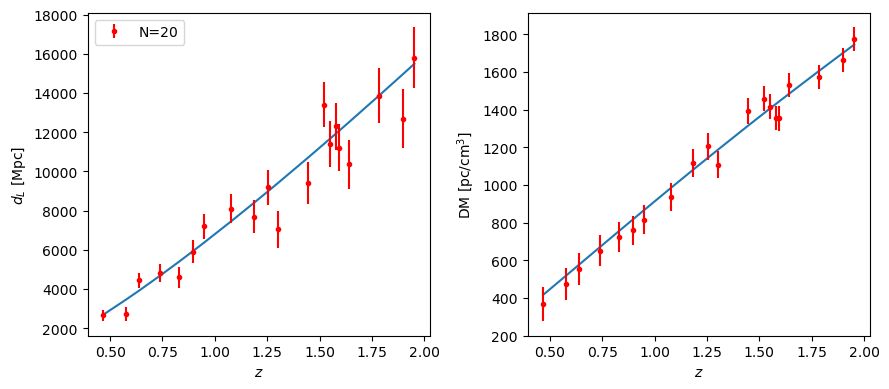

In [9]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(np.sort(z_centre), np.sort(dL_centre))
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=3, c='r', label=f'N={len(z_centre)}')
ax1.set_ylabel(r'$d_{L}$ [Mpc]')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left')

ax2.plot(np.sort(z_centre), np.sort(DM_centre))
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=3, c='r')
ax2.set_ylabel(r'DM [pc/cm$^3$]')
ax2.set_xlabel(r'$z$')

plt.tight_layout()
plt.show()

In [10]:
events=pd.DataFrame({
    'z': z_centre,
    'dL': dL_centre,
    'dL_obs': dL_obs_centre,
    's_dL': sigma_dL,
    'DM': DM_centre,
    'DM_obs': DM_obs_centre,
    's_DM': s_DM_obs
})
events.head()

,z,dL,dL_obs,s_dL,DM,DM_obs,s_DM
0,1.184770,8378.423595,7681.742812,837.842359,1081.610647,1116.522295,72.305398
1,1.898998,14967.406479,12698.246853,1496.740648,1700.813409,1663.930003,61.905176
2,1.520240,11392.329905,13401.638053,1139.232991,1379.322762,1458.612387,66.832801
3,1.549098,11658.907417,11414.221049,1165.890742,1404.369069,1415.694987,66.416354
4,0.466934,2691.992355,2660.635260,269.199235,415.452421,366.890213,90.079712


In [11]:
# initial parameters
Hubble0 = 70
Omega0 = 0.3
w0 = -1.0

# MCMC parameters
N_WALKERS = 100
HEATING = 500
N_STEPS = 1000

In [12]:
# Main execution
if __name__ == "__main__":

    # Define initial parameters: [F, HOf, sigma_host, e_mu]
    initial_params = np.array([Hubble0, Omega0, w0])

    # Run MCMC
    sampler = run_mcmc(events, initial_params, nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS)

Running MCMC...
heating...


Acceptance fraction: 0.226: 100%|██████████| 500/500 [6:06:32<00:00, 43.98s/it]  


main running...


Acceptance fraction: 0.228: 100%|██████████| 1000/1000 [12:33:43<00:00, 45.22s/it] 

final acceptance fraction: 0.227


In [15]:
# Analyze results
samples, params_median, params_errors = mcmc_analyze_results(sampler, burn_in=HEATING)

# Print results
param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
print("MCMC Results:")
for i, name in enumerate(param_names):
    print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

# Save samples to file for later analysis if needed
np.save('./posterior/GW_FRB_MCMC.npy', samples)

MCMC Results:
$ H_0$  = 68.797 ± 1.897
$ \Omega_m$  = 0.377 ± 0.207
$ w$  = -1.243 ± 0.862


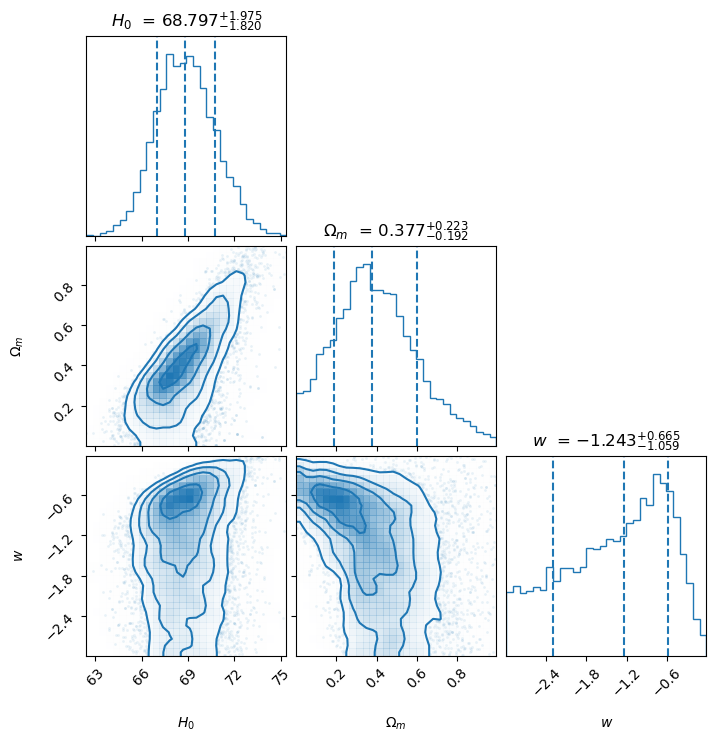

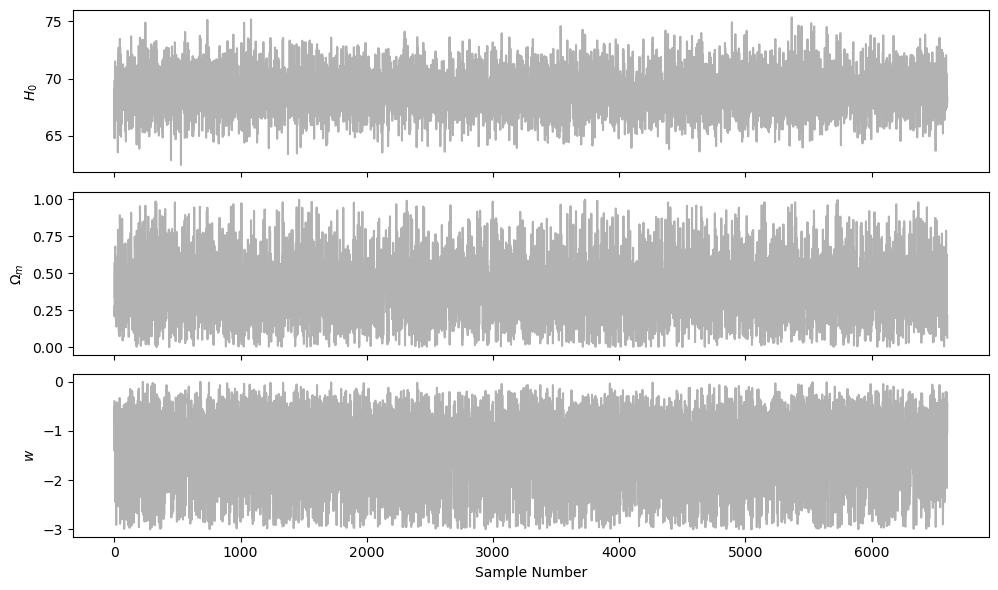

In [16]:
param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
    
mcmc_plot_results(samples, param_names, savetitle=None)